In [1]:
import pandas as pd

# Chargement du dataset (ajustez le chemin selon votre dossier sur Windows)
df = pd.read_csv('creditcard.csv')

# Renommage des colonnes
traductions = {
    'Time': 'Temps_Ecoule',
    'Amount': 'Montant_Transaction',
    'Class': 'Cible_Fraude'
}

# Pour les colonnes V1 à V28, nous garderons le nom technique car ce sont des 
# composants issus d'une PCA (Analyse en Composantes Principales)
df.rename(columns=traductions, inplace=True)

print(df.columns)

Index(['Temps_Ecoule', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
       'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',
       'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28',
       'Montant_Transaction', 'Cible_Fraude'],
      dtype='str')


In [2]:
# Affiche le type de chaque colonne et le nombre de valeurs non-nulles
print("--- Types de données ---")
print(df.info())


--- Types de données ---
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Temps_Ecoule         284807 non-null  float64
 1   V1                   284807 non-null  float64
 2   V2                   284807 non-null  float64
 3   V3                   284807 non-null  float64
 4   V4                   284807 non-null  float64
 5   V5                   284807 non-null  float64
 6   V6                   284807 non-null  float64
 7   V7                   284807 non-null  float64
 8   V8                   284807 non-null  float64
 9   V9                   284807 non-null  float64
 10  V10                  284807 non-null  float64
 11  V11                  284807 non-null  float64
 12  V12                  284807 non-null  float64
 13  V13                  284807 non-null  float64
 14  V14                  284807 non-null  float64
 15  V15

In [3]:
print("--- Valeurs manquantes ---")
print(df.isnull().sum())


--- Valeurs manquantes ---
Temps_Ecoule           0
V1                     0
V2                     0
V3                     0
V4                     0
V5                     0
V6                     0
V7                     0
V8                     0
V9                     0
V10                    0
V11                    0
V12                    0
V13                    0
V14                    0
V15                    0
V16                    0
V17                    0
V18                    0
V19                    0
V20                    0
V21                    0
V22                    0
V23                    0
V24                    0
V25                    0
V26                    0
V27                    0
V28                    0
Montant_Transaction    0
Cible_Fraude           0
dtype: int64


In [4]:
# Compter le nombre de lignes identiques
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons détectés : {nb_doublons}")

# Si tu veux les supprimer pour nettoyer ton dataset :
if nb_doublons > 0:
    df.drop_duplicates(inplace=True)
    print("Doublons supprimés !")

Nombre de doublons détectés : 1081
Doublons supprimés !


In [5]:
# Affiche les statistiques pour toutes les colonnes numériques
print(df.describe())

        Temps_Ecoule             V1             V2             V3  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean    94811.077600       0.005917      -0.004135       0.001613   
std     47481.047891       1.948026       1.646703       1.508682   
min         0.000000     -56.407510     -72.715728     -48.325589   
25%     54204.750000      -0.915951      -0.600321      -0.889682   
50%     84692.500000       0.020384       0.063949       0.179963   
75%    139298.000000       1.316068       0.800283       1.026960   
max    172792.000000       2.454930      22.057729       9.382558   

                  V4             V5             V6             V7  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean       -0.002966       0.001828      -0.001139       0.001801   
std         1.414184       1.377008       1.331931       1.227664   
min        -5.683171    -113.743307     -26.160506     -43.557242   
25%        -0.850134      -0.6898

In [6]:
# Statistiques détaillées pour le montant
print(df['Montant_Transaction'].describe())

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Montant_Transaction, dtype: float64


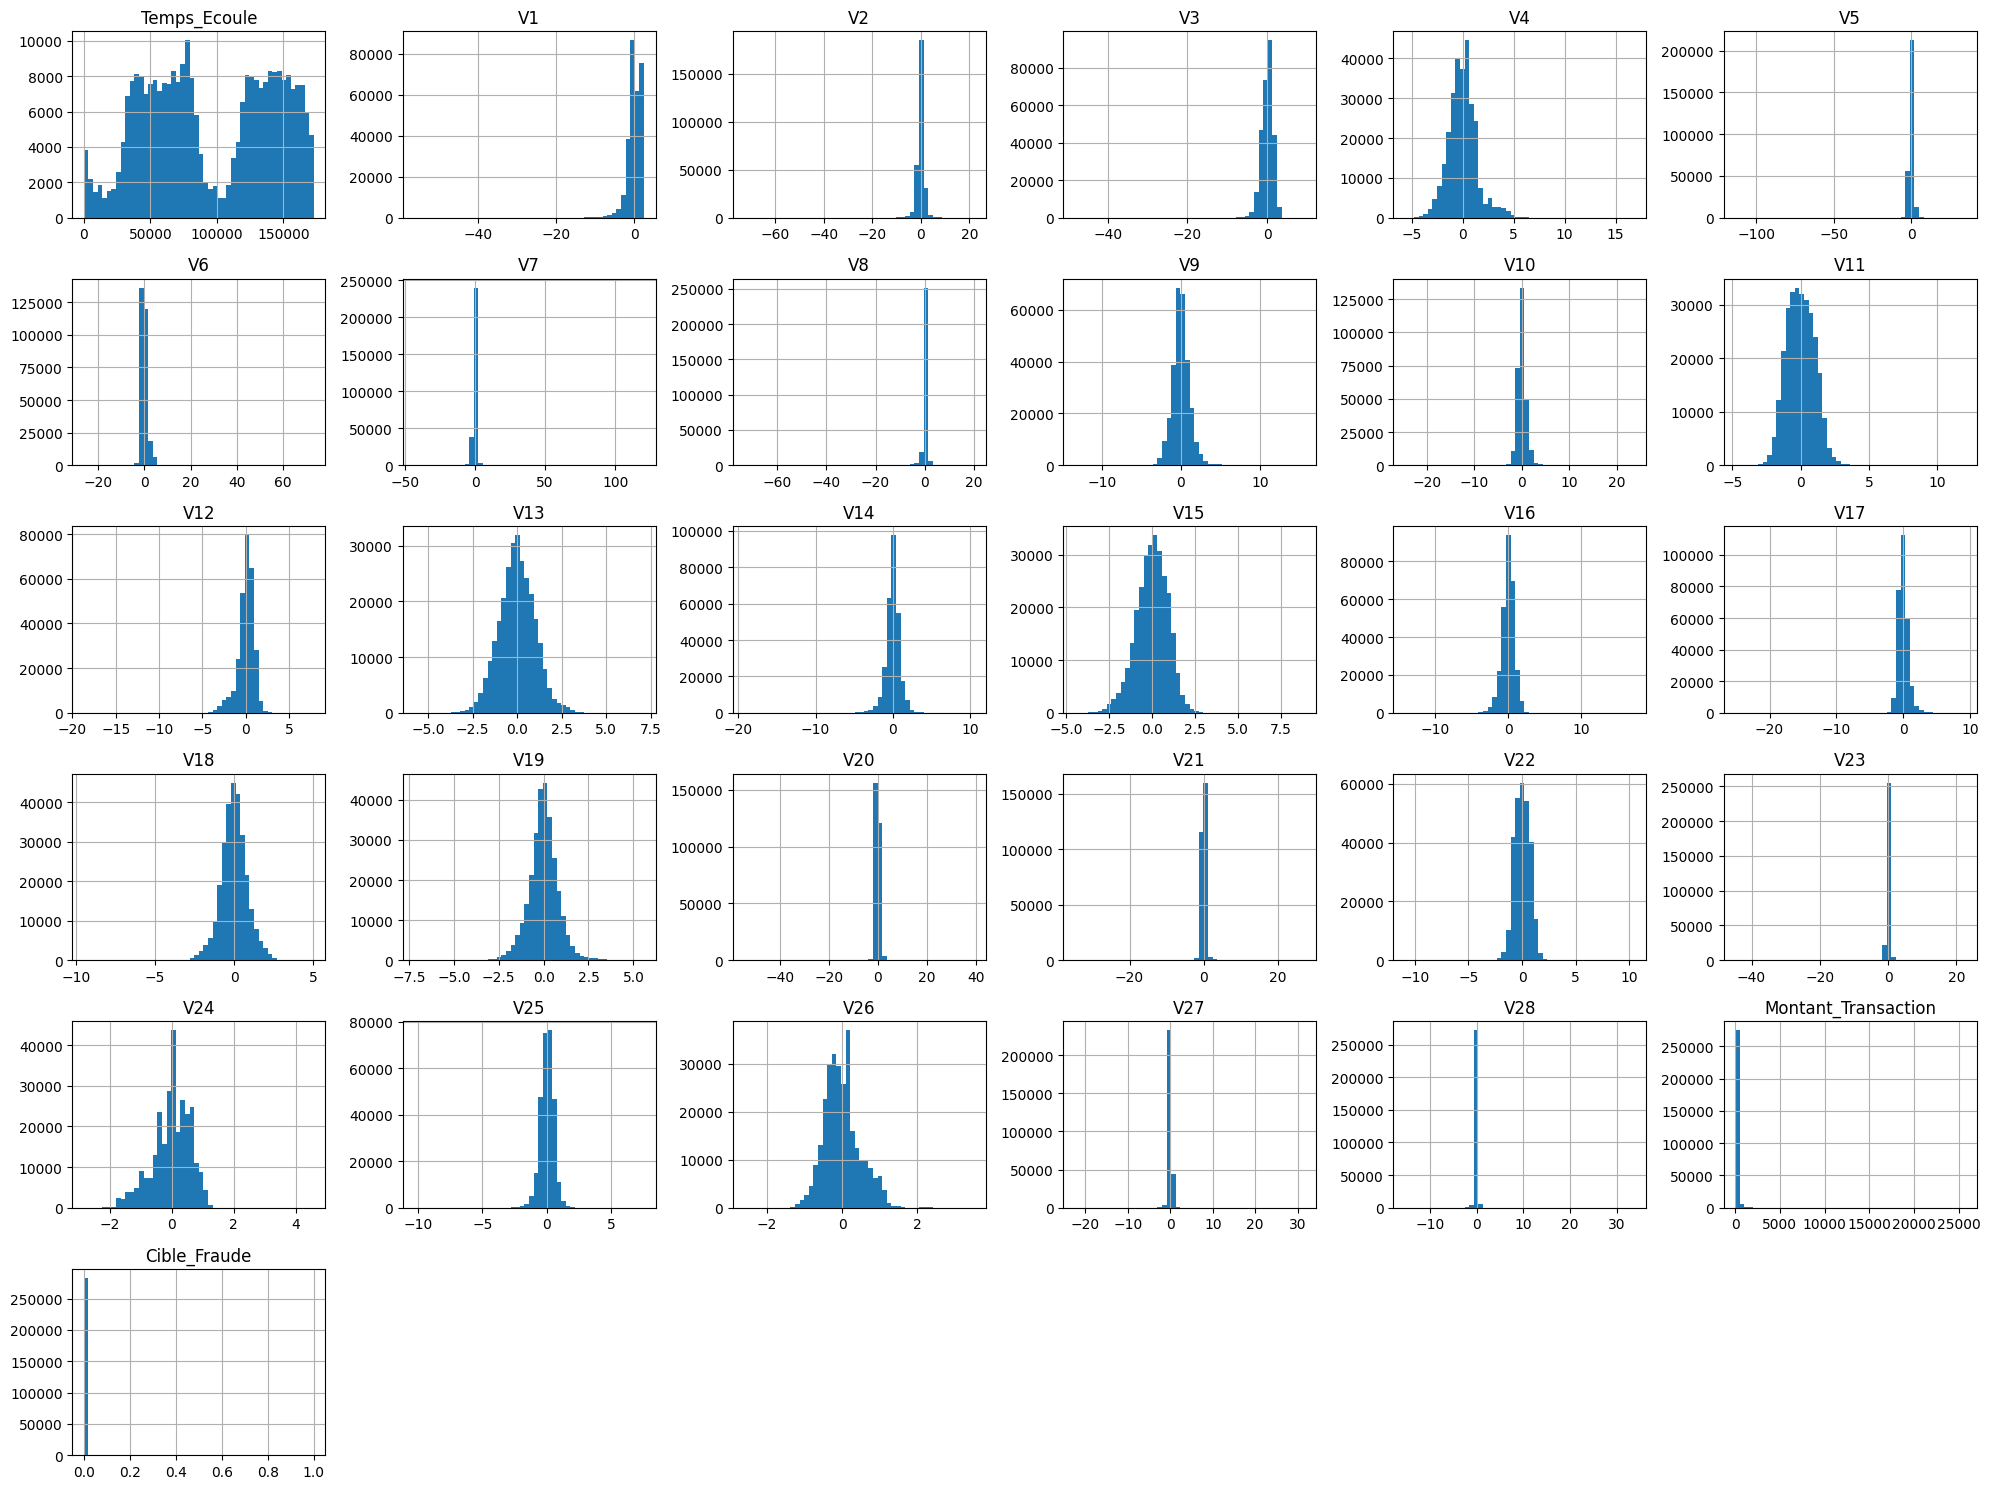

In [7]:
import matplotlib.pyplot as plt

# Configuration de la taille de la figure (Largeur, Hauteur)
df.hist(figsize=(20, 15), bins=50)

# Ajuster l'espacement pour que les titres ne se chevauchent pas
plt.tight_layout()
plt.show()

In [8]:
# Vérifie bien les noms des colonnes dans ton code de la Phase 3 !
# Si tu as suivi mon code précédent, les noms sont :
colonnes_visu = ['Heure_Scaled', 'V1', 'V2', 'V3', 'Amount_Scaled', 'Class'] 

# On s'assure que Class est bien le nom de ta cible (parfois c'est 'Cible_Fraude')
# On crée l'échantillon à nouveau pour être sûr
df_sample = df.sample(n=1000, random_state=42)

# Affichage du pairplot


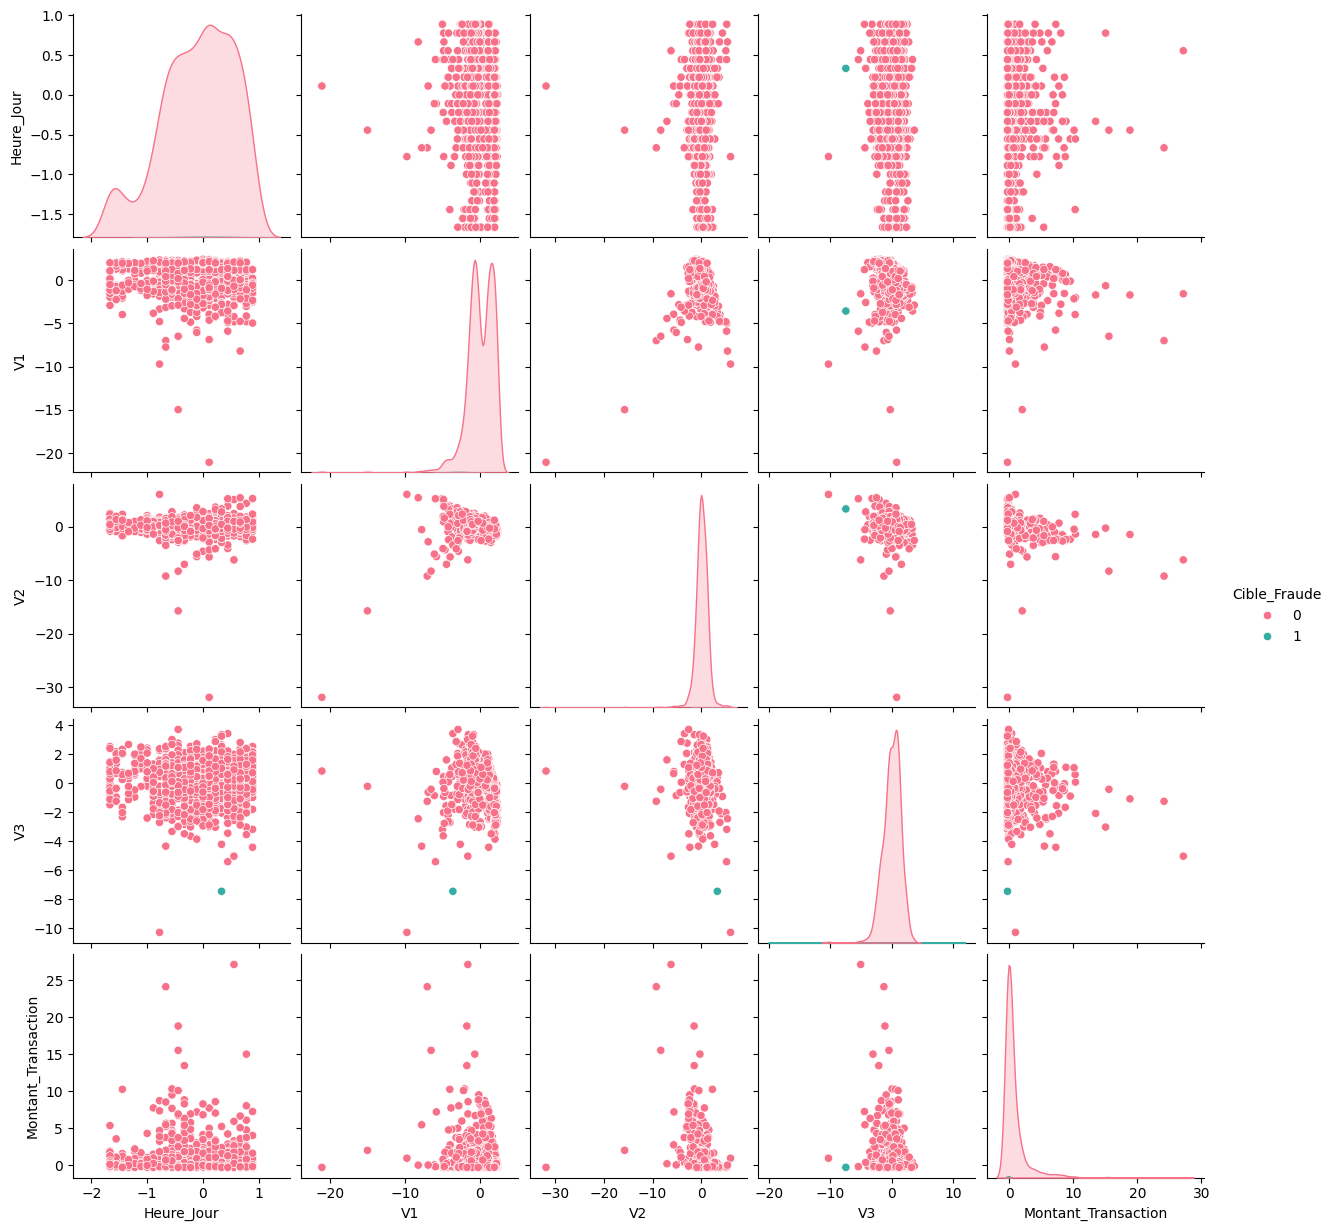

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. On utilise les noms exacts de tes colonnes
colonnes_visu = ['Heure_Jour', 'V1', 'V2', 'V3', 'Montant_Transaction', 'Cible_Fraude'] 

# 2. Création de l'échantillon (on vérifie que les colonnes existent bien dans df)
df_sample = df[colonnes_visu].sample(n=1000, random_state=42)

# 3. Affichage du pairplot
# On utilise 'Cible_Fraude' pour colorer les points (hue)
sns.pairplot(df_sample, hue='Cible_Fraude', palette='husl', diag_kind='kde')

# 4. Affichage
plt.show()

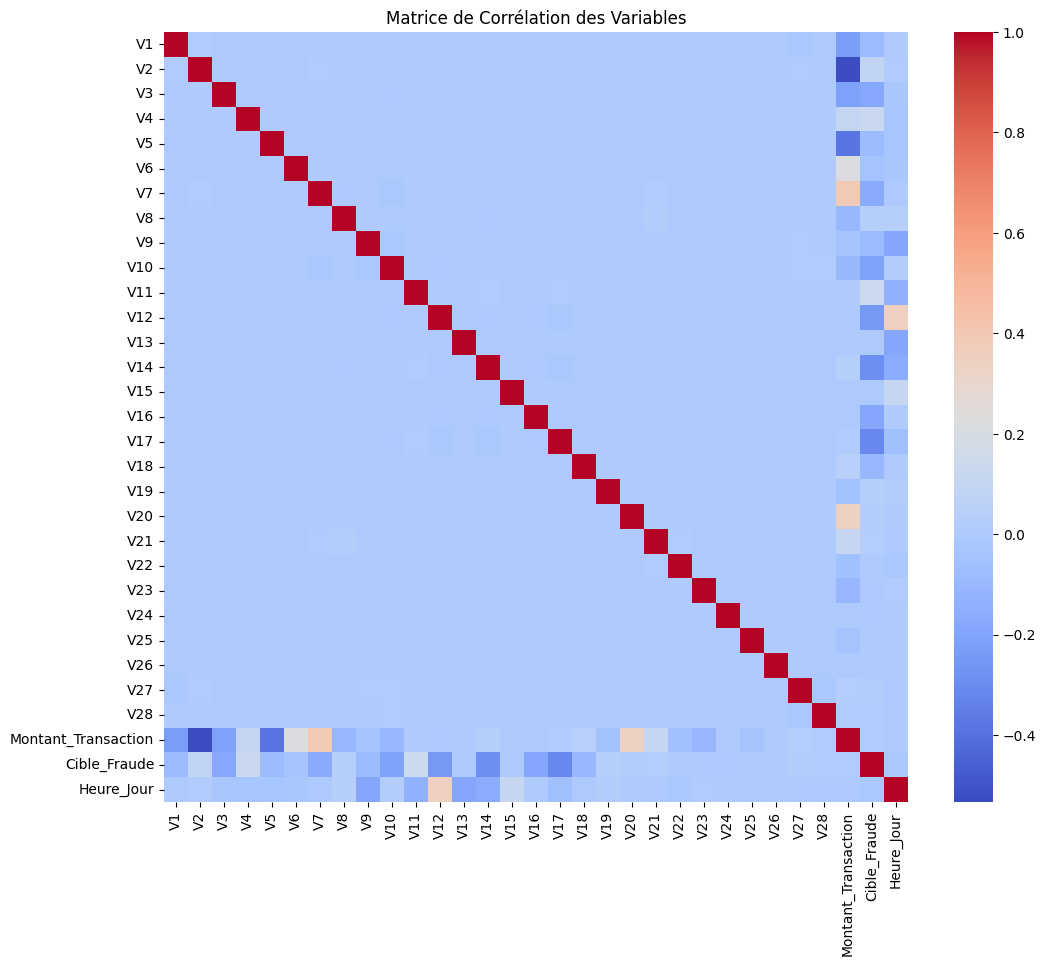

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# On calcule la corrélation entre toutes les colonnes
corr = df.corr()

# On prépare la figure
plt.figure(figsize=(12, 10))

# On trace la heatmap (carte de chaleur)
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f")

plt.title('Matrice de Corrélation des Variables')
plt.show()

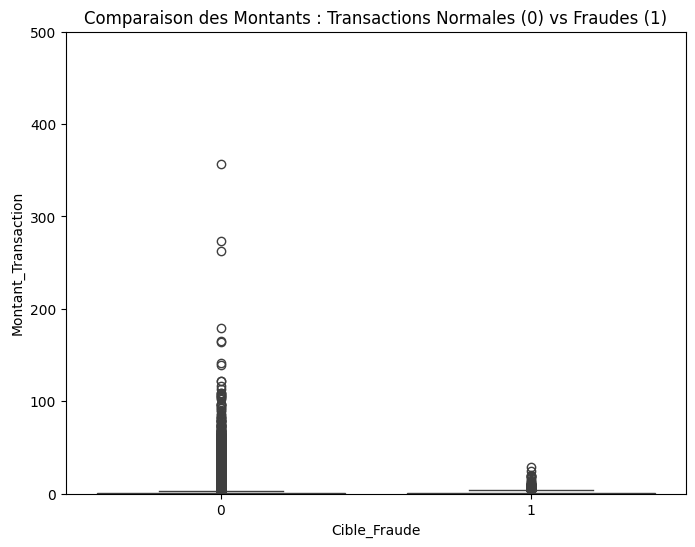

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Création du boxplot pour comparer le montant selon la classe
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cible_Fraude', y='Montant_Transaction', data=df)

# On limite l'axe Y car les gros outliers empêchent de voir la "boîte"
plt.ylim(0, 500) 
plt.title('Comparaison des Montants : Transactions Normales (0) vs Fraudes (1)')
plt.show()

In [30]:
# 1. Création de la colonne 'Heure_Jour'
# On divise par 3600 (secondes dans une heure) et on utilise % 24 pour rester entre 0 et 23
df['Heure_Jour'] = (df['Temps_Ecoule'] // 3600) % 24

# 2. Vérification visuelle
# On affiche les premières lignes pour voir la nouvelle colonne à la fin
print(df[['Temps_Ecoule', 'Heure_Jour']].head())

KeyError: 'Temps_Ecoule'

In [39]:
from sklearn.preprocessing import RobustScaler

# 1. Initialisation
rob_scaler = RobustScaler()

# 2. Transformation
# On utilise RobustScaler car il est moins sensible aux valeurs aberrantes (outliers)
df['Montant_Transaction'] = rob_scaler.fit_transform(df['Montant_Transaction'].values.reshape(-1, 1))
df['Heure_Jour'] = rob_scaler.fit_transform(df['Heure_Jour'].values.reshape(-1, 1))

# 3. Vérification
print("Scaling terminé !")
print(df[['Montant_Transaction', 'Heure_Jour']].head())

Scaling terminé !
   Montant_Transaction  Heure_Jour
0             1.774718   -1.666667
1            -0.268530   -1.666667
2             4.959811   -1.666667
3             1.411487   -1.666667
4             0.667362   -1.666667


In [40]:
# Note les doubles crochets [[ ]]
print(df[['Heure_Jour', 'Montant_Transaction']].describe())

          Heure_Jour  Montant_Transaction
count  283726.000000        283726.000000
mean       -0.106039             0.924387
std         0.648313             3.482123
min        -1.666667            -0.305938
25%        -0.555556            -0.228063
50%         0.000000             0.000000
75%         0.444444             0.771937
max         0.888889           356.962314


In [46]:
from sklearn.model_selection import train_test_split

# 1. On sépare les caractéristiques (X) de la réponse (y)
X = df.drop('Cible_Fraude', axis=1) # Tout sauf la colonne fraude
y = df['Cible_Fraude']              # Uniquement la colonne fraude

# 2. On découpe en 80% / 20%
# test_size=0.20 signifie 20% pour le test
# random_state=42 c'est comme une graine : ça permet d'avoir toujours le même mélange
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42,stratify=y)

print(f"Données d'entraînement : {X_train.shape[0]} lignes")
print(f"Données de test : {X_test.shape[0]} lignes")
print(f"Nombre de fraudes dans le groupe de test : {y_test.sum()}")

Données d'entraînement : 226980 lignes
Données de test : 56746 lignes
Nombre de fraudes dans le groupe de test : 95


In [51]:
from sklearn.linear_model import LogisticRegression

# Création du modèle
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)

# Apprentissage
model_lr.fit(X_train, y_train)

print("✅ Modèle Baseline (Simple) : Entraîné !")

✅ Modèle Baseline (Simple) : Entraîné !


In [52]:
from sklearn.ensemble import RandomForestClassifier

# On utilise n_jobs=-1 pour que ton PC utilise toute sa puissance
model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)

print("Entraînement en cours... (Max 60 secondes)")
model_rf.fit(X_train, y_train)
print("✅ Random Forest entraîné avec succès !")

Entraînement en cours... (Max 60 secondes)
✅ Random Forest entraîné avec succès !


In [53]:
from xgboost import XGBClassifier
import time

# scale_pos_weight = (nombre de non-fraudes / nombre de fraudes)
# Ça aide le modèle à se concentrer sur le petit 0.17%
model_xgb = XGBClassifier(scale_pos_weight=580, tree_method='hist', random_state=42)

print("Entraînement du champion XGBoost...")
start = time.time()

model_xgb.fit(X_train, y_train)

end = time.time()
print(f"✅ XGBoost terminé en {end - start:.2f} secondes !")

Entraînement du champion XGBoost...
✅ XGBoost terminé en 4.71 secondes !


In [65]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. On utilise TOUTES les données d'entraînement (X_train)
# 2. On garde 5 splits pour bien vérifier la stabilité
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. On remet le poids correct pour la fraude
model_final = XGBClassifier(scale_pos_weight=580, tree_method='hist', random_state=42)

print("⏳ Calcul sur le dataset complet (ça peut prendre 10-20 secondes)...")
scores_finaux = cross_val_score(model_final, X_train, y_train, cv=skf, scoring='recall')

print(f"📊 Scores finaux : {scores_finaux}")
print(f"✅ Moyenne : {scores_finaux.mean():.2%}")
print(f"✅ Stabilité (Écart-type) : {scores_finaux.std():.4f}")

⏳ Calcul sur le dataset complet (ça peut prendre 10-20 secondes)...
📊 Scores finaux : [0.78666667 0.84       0.75       0.88157895 0.86842105]
✅ Moyenne : 82.53%
✅ Stabilité (Écart-type) : 0.0498


--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746

L'AUC de ton modèle est de : 0.9246


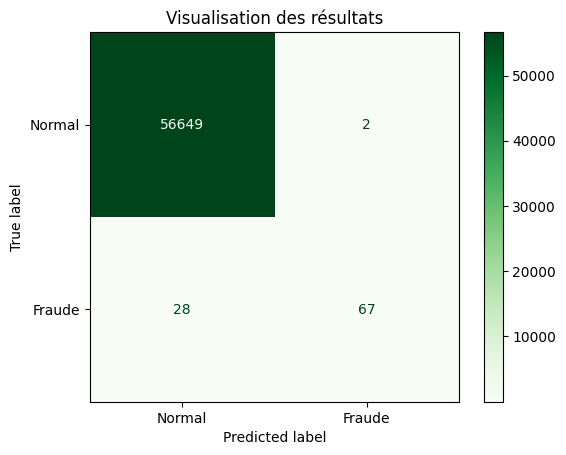

In [68]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Prédictions
y_pred = model_rf.predict(X_test)
y_proba = model_rf.predict_proba(X_test)[:, 1]

# 2. Rapport détaillé (Precision, Recall, F1)
print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))

# 3. Score AUC
auc = roc_auc_score(y_test, y_proba)
print(f"L'AUC de ton modèle est de : {auc:.4f}")

# 4. Affichage de la Matrice de Confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraude'])
disp.plot(cmap='Greens')
plt.title("Visualisation des résultats")
plt.show()